# Student Academic Performance & Risk Prediction

## Objective
Build a machine learning system that predicts student academic performance and identifies students who may be at academic risk.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.model_selection import train_test_split as tts
from sklearn.compose import ColumnTransformer as ct
from sklearn.preprocessing import OneHotEncoder as ohe
from sklearn.pipeline import Pipeline as pl
from sklearn.linear_model import LinearRegression as lr
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student-scores.csv to student-scores.csv


In [ ]:
df = pd.read_csv('student-scores.csv')
print(df.head())
print("\nshape :\n",df.shape)
print("\ncolumns :\n",df.columns)


   id first_name last_name                                  email  gender  \
0   1       Paul     Casey         paul.casey.1@gslingacademy.com    male   
1   2   Danielle  Sandoval  danielle.sandoval.2@gslingacademy.com  female   
2   3       Tina   Andrews       tina.andrews.3@gslingacademy.com  female   
3   4       Tara     Clark         tara.clark.4@gslingacademy.com  female   
4   5    Anthony    Campos     anthony.campos.5@gslingacademy.com    male   

   part_time_job  absence_days  extracurricular_activities  \
0          False             3                       False   
1          False             2                       False   
2          False             9                        True   
3          False             5                       False   
4          False             5                       False   

   weekly_self_study_hours   career_aspiration  math_score  history_score  \
0                       27              Lawyer          73             81   
1         

In [ ]:
print(df.info())
print("\nNumber of Missing Values :\n",df.isnull().sum())
print("\nStatistics :\n",df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-null   int64 
 7   extracurricular_activities  2000 non-null   bool  
 8   weekly_self_study_hours     2000 non-null   int64 
 9   career_aspiration           2000 non-null   object
 10  math_score                  2000 non-null   int64 
 11  history_score               2000 non-null   int64 
 12  physics_score               2000 non-null   int64 
 13  chemistry_score             2000 non-null   int6

In [ ]:
print(df.gender.value_counts())
print("\n",df.part_time_job.value_counts())
print("\n",df.extracurricular_activities.value_counts())
print("\n",df.career_aspiration.value_counts())

gender
female    1002
male       998
Name: count, dtype: int64

 part_time_job
False    1684
True      316
Name: count, dtype: int64

 extracurricular_activities
False    1592
True      408
Name: count, dtype: int64

 career_aspiration
Software Engineer        315
Business Owner           309
Unknown                  223
Banker                   169
Lawyer                   138
Accountant               126
Doctor                   119
Real Estate Developer     83
Stock Investor            73
Construction Engineer     68
Artist                    67
Game Developer            63
Government Officer        61
Teacher                   59
Designer                  56
Scientist                 39
Writer                    32
Name: count, dtype: int64


In [ ]:
subject_columns = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score' ,'geography_score']
df['overall_score']=df[subject_columns].mean(axis=1)

print(df.overall_score.head())
print(df.overall_score.describe())

0    82.000000
1    91.428571
2    86.428571
3    78.714286
4    74.428571
Name: overall_score, dtype: float64
count    2000.000000
mean       80.980357
std         6.042224
min        59.142857
25%        77.285714
50%        81.000000
75%        84.714286
max        96.142857
Name: overall_score, dtype: float64


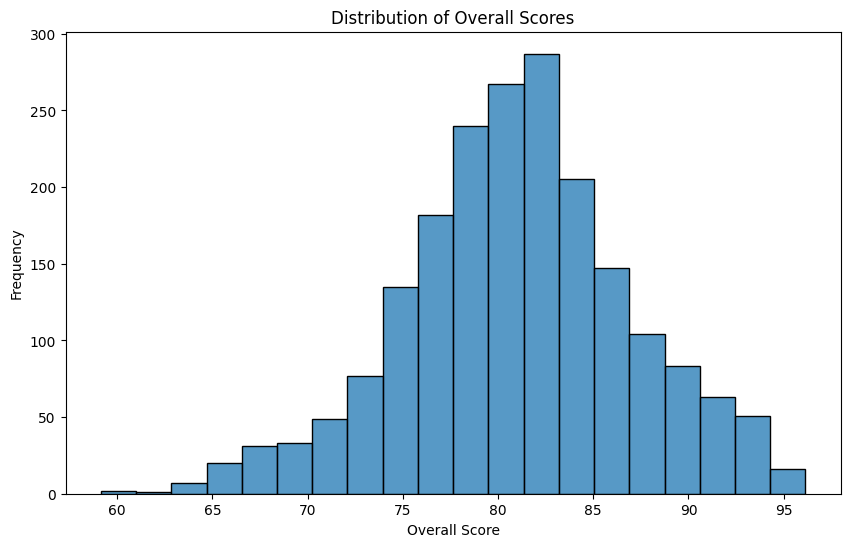

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['overall_score'], bins=20)
plt.gca().set_xlabel("Overall Score")
plt.gca().set_ylabel("Frequency")
plt.title('Distribution of Overall Scores')
plt.show()

In [ ]:
df[['absence_days','weekly_self_study_hours','overall_score']].corr()

,absence_days,weekly_self_study_hours,overall_score
absence_days,1.000000,-0.286086,-0.232868
weekly_self_study_hours,-0.286086,1.000000,0.501520
overall_score,-0.232868,0.501520,1.000000


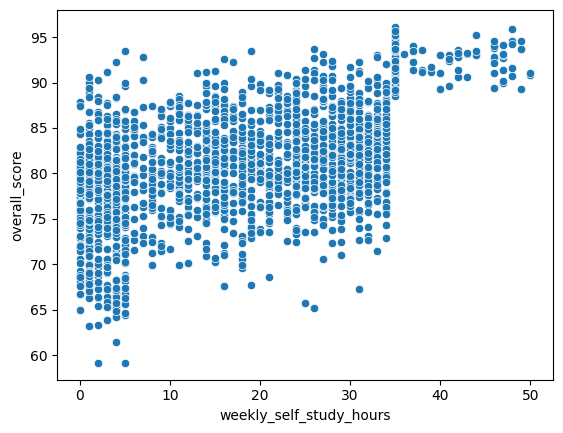

In [ ]:
sns.scatterplot(x='weekly_self_study_hours',y='overall_score',data=df)
plt.show()

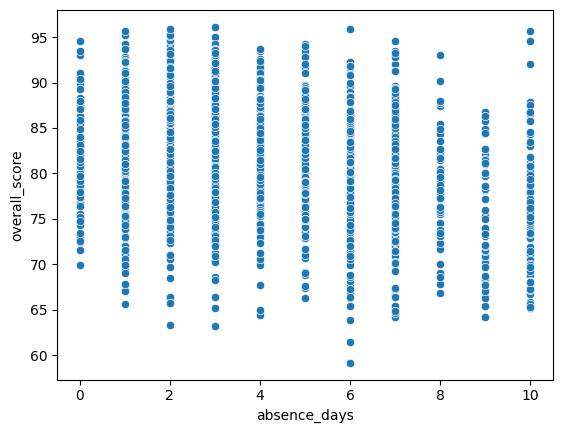

In [ ]:
sns.scatterplot(x='absence_days',y='overall_score',data=df)
plt.show()

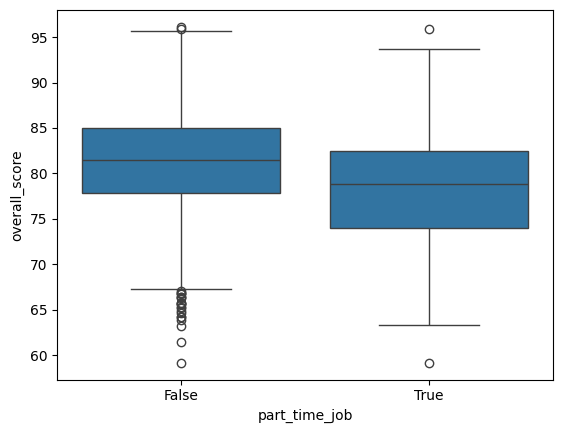

In [ ]:
sns.boxplot(x='part_time_job',y='overall_score',data=df)
plt.show()

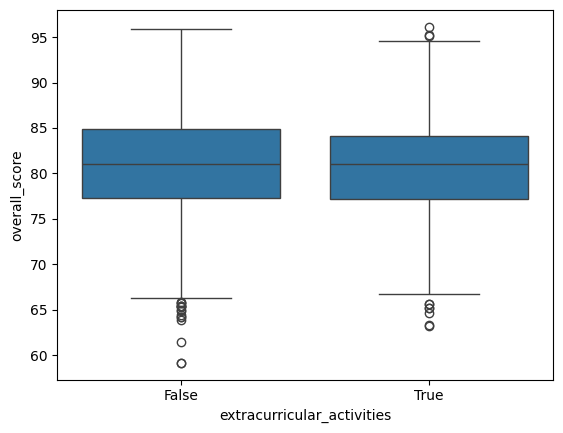

In [ ]:
sns.boxplot(x='extracurricular_activities',y='overall_score',data=df)
plt.show()

In [ ]:
df.groupby('career_aspiration')['overall_score'].mean().sort_values(ascending=False)

,overall_score
career_aspiration,
Doctor,89.678271
Scientist,86.435897
Lawyer,84.157350
Writer,84.053571
Construction Engineer,83.470588
Designer,82.405612
Software Engineer,82.214966
Banker,81.868977
Game Developer,81.784580


In [ ]:
df['career_aspiration'].value_counts()

,count
career_aspiration,
Software Engineer,315
Business Owner,309
Unknown,223
Banker,169
Lawyer,138
Accountant,126
Doctor,119
Real Estate Developer,83
Stock Investor,73


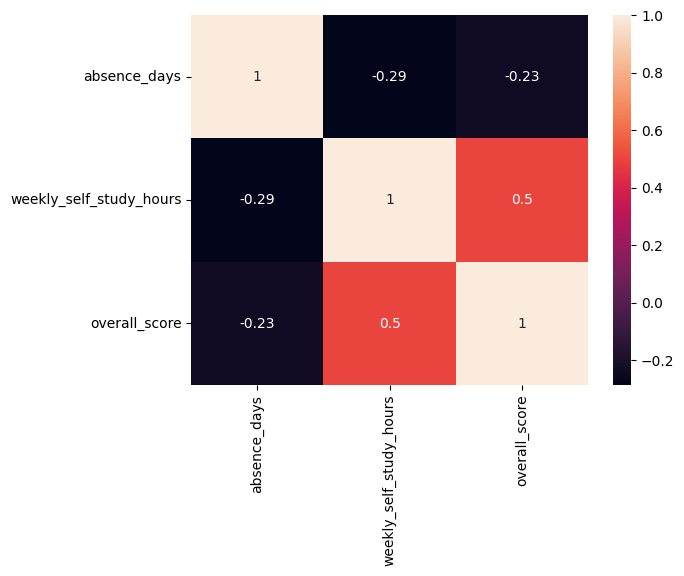

In [ ]:
corr=df[['absence_days','weekly_self_study_hours','overall_score']].corr()

sns.heatmap(corr,annot=True)
plt.show()

In [ ]:
X = df[['gender','part_time_job','absence_days','extracurricular_activities','weekly_self_study_hours','career_aspiration']]
Y = df['overall_score']

print(X.shape)
print(Y.shape)

(2000, 6)
(2000,)


In [ ]:
X_train, X_test, Y_train, Y_test = tts(X, Y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1600, 6)
(400, 6)
(1600,)
(400,)


In [ ]:
numeric_features = ['absence_days','weekly_self_study_hours']
categorical_features = ['gender','part_time_job','extracurricular_activities','career_aspiration']

preprocessor = ct(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', ohe(handle_unknown='ignore'), categorical_features)
    ])

pipeline = pl(steps=[('preprocessor', preprocessor),
                     ('linear_model', lr())])

pipeline.fit(X_train, Y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['absence_days',
                                                   'weekly_self_study_hours']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'part_time_job',
                                                   'extracurricular_activities',
                                                   'career_aspiration'])])),
                ('linear_model', LinearRegression())])

In [ ]:
y_pred=pipeline.predict(X_test)

y_pred[:10]

array([80.87945504, 81.2180489 , 81.22333364, 79.47818673, 81.284145  ,
       81.91480483, 78.17085695, 84.49958945, 74.45825165, 81.54575189])

In [ ]:
mae = mean_absolute_error(Y_test, y_pred)
rmse = mean_squared_error(Y_test, y_pred)**0.5
r2 = r2_score(Y_test, y_pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 4.06462773624716
RMSE: 5.120048850953598
R2: 0.38961289887996864


In [ ]:
from sklearn.tree import DecisionTreeRegressor as dtr

tree_model = pl(steps=[('preprocessor', preprocessor),
                     ('decision_tree', dtr(random_state = 42))])

tree_model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['absence_days',
                                                   'weekly_self_study_hours']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'part_time_job',
                                                   'extracurricular_activities',
                                                   'career_aspiration'])])),
                ('decision_tree', DecisionTreeRegressor(random_state=42))])

In [ ]:
tree_pred = tree_model.predict(X_test)

tree_mae = mean_absolute_error(Y_test, tree_pred)
tree_rmse = mean_squared_error(Y_test, tree_pred)**0.5
tree_r2 = r2_score(Y_test, tree_pred)

print("MAE:",tree_mae)
print("RMSE:",tree_rmse)
print("R2:",tree_r2)

MAE: 4.831964285714285
RMSE: 6.232005501738276
R2: 0.09569945152879211


In [ ]:
from sklearn.ensemble import RandomForestRegressor as RandomForestRegressor

rf_model = pl(steps=[('preprocessor', preprocessor),
                     ('random_forest', RandomForestRegressor(random_state = 42))])

rf_model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['absence_days',
                                                   'weekly_self_study_hours']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'part_time_job',
                                                   'extracurricular_activities',
                                                   'career_aspiration'])])),
                ('random_forest', RandomForestRegressor(random_state=42))])

In [ ]:
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_rmse = mean_squared_error(Y_test, rf_pred)**0.5
rf_r2 = r2_score(Y_test, rf_pred)

print("MAE:",rf_mae)
print("RMSE:",rf_rmse)
print("R2:",rf_r2)

MAE: 4.016485909863949
RMSE: 5.209169596344655
R2: 0.3681788897921934


In [ ]:
forest = rf_model.named_steps['random_forest']
preprocessor_fitted = rf_model.named_steps['preprocessor']
feature_names=preprocessor_fitted.get_feature_names_out()
importances = forest.feature_importances_
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
feature_importance

,Feature,Importance
1,num__weekly_self_study_hours,0.416599
11,cat__career_aspiration_Business Owner,0.197223
0,num__absence_days,0.148716
14,cat__career_aspiration_Doctor,0.025119
2,cat__gender_female,0.023673
3,cat__gender_male,0.022802
6,cat__extracurricular_activities_False,0.018798
7,cat__extracurricular_activities_True,0.018458
23,cat__career_aspiration_Unknown,0.014797
5,cat__part_time_job_True,0.014784


In [ ]:
X_no_career=X.drop(columns=['career_aspiration'])
X_no_career.shape

(2000, 5)

In [ ]:
X_no_career_train, X_no_career_test, Y_no_career_train, Y_no_career_test = tts(X_no_career, Y, test_size=0.2, random_state=42)
categorical_features_nc=[
    'gender',
    'part_time_job',
    'extracurricular_activities'
]
numeric_features_nc=[
    'absence_days',
    'weekly_self_study_hours'
]
preprocessor_nc = ct(
    transformers=[
        ('num', 'passthrough', numeric_features_nc),
        ('cat', ohe(handle_unknown='ignore'), categorical_features_nc)
    ])
forest_model_nc = pl(steps=[('preprocessor', preprocessor_nc),
                     ('random_forest', RandomForestRegressor(n_estimators = 100 , random_state = 42))])

In [ ]:
forest_model_nc.fit(X_no_career_train, Y_no_career_train)
y_pred_nc=forest_model_nc.predict(X_no_career_test)

mae_nc = mean_absolute_error(Y_no_career_test, y_pred_nc)
rmse_nc = mean_squared_error(Y_no_career_test, y_pred_nc)**0.5
r2_nc = r2_score(Y_no_career_test, y_pred_nc)

print("MAE:",mae_nc)
print("RMSE:",rmse_nc)
print("R2:",r2_nc)

MAE: 4.515140183080807
RMSE: 5.827147351779916
R2: 0.20937755626766175


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor as gbr
gbr_pipeline = pl(steps=[('preprocessor', preprocessor),
                     ('gradient_boosting', gbr(random_state = 42))])
gbr_pipeline.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['absence_days',
                                                   'weekly_self_study_hours']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'part_time_job',
                                                   'extracurricular_activities',
                                                   'career_aspiration'])])),
                ('gradient_boosting',
                 GradientBoostingRegressor(random_state=42))])

In [ ]:
gbr_pred = gbr_pipeline.predict(X_test)

gbr_mae = mean_absolute_error(Y_test, gbr_pred)
gbr_rmse = mean_squared_error(Y_test, gbr_pred)**0.5
gbr_r2 = r2_score(Y_test, gbr_pred)

print("MAE:",gbr_mae)
print("RMSE:",gbr_rmse)
print("R2:",gbr_r2)

MAE: 3.8033262480739847
RMSE: 4.876269793056596
R2: 0.4463534596665778


In [ ]:
results = pd.DataFrame({'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Random Forest (No Career)', 'Gradient Boosting'],
                   'MAE': [mae, tree_mae, rf_mae, mae_nc, gbr_mae],
                   'RMSE': [rmse, tree_rmse, rf_rmse, rmse_nc, gbr_rmse],
                   'R2': [r2, tree_r2, rf_r2, r2_nc, gbr_r2]})
results

,Model,MAE,RMSE,R2
0,Linear Regression,4.064628,5.120049,0.389613
1,Decision Tree,4.831964,6.232006,0.095699
2,Random Forest,4.016486,5.209170,0.368179
3,Random Forest (No Career),4.515140,5.827147,0.209378
4,Gradient Boosting,3.803326,4.876270,0.446353


In [ ]:
from sklearn.model_selection import cross_val_score as cvs

cv_scores = cvs(gbr_pipeline, X, Y, cv=5, scoring='r2')
print(cv_scores)
print("Mean R2:",cv_scores.mean())

[0.43320766 0.45511158 0.3787458  0.40710183 0.49859367]
Mean R2: 0.43455210814571227


In [ ]:
from sklearn.model_selection import GridSearchCV as gscv

param_grid={
    'gradient_boosting__n_estimators':[100,200,300],
    'gradient_boosting__learning_rate':[0.03,0.05,0.1],
    'gradient_boosting__max_depth':[2,3,4]
}

In [ ]:
grid_search = gscv(gbr_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X,Y)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'gradient_boosting__learning_rate': 0.05, 'gradient_boosting__max_depth': 2, 'gradient_boosting__n_estimators': 200}
0.4483100475868239


In [ ]:
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)

best_mae = mean_absolute_error(Y_test, best_pred)
best_rmse = mean_squared_error(Y_test, best_pred)**0.5
best_r2 = r2_score(Y_test, best_pred)

print("MAE:",best_mae)
print("RMSE:",best_rmse)
print("R2:",best_r2)

MAE: 3.6603649123060866
RMSE: 4.73894524359497
R2: 0.4770977393503474


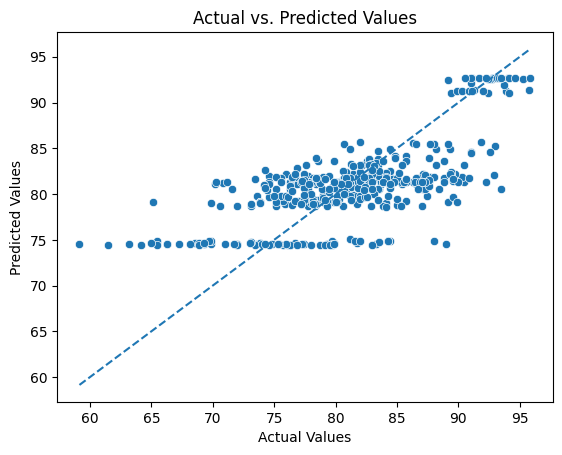

In [ ]:
sns.scatterplot(x=Y_test,y=best_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.plot([Y_test.min(),Y_test.max()],
         [Y_test.min(),Y_test.max()],
         linestyle='--')
plt.show()

In [ ]:
residuals = Y_test - best_pred
residuals.describe()

,overall_score
count,400.000000
mean,0.260256
std,4.737719
min,-15.420180
25%,-2.567224
50%,0.136204
75%,2.881982
max,14.436963


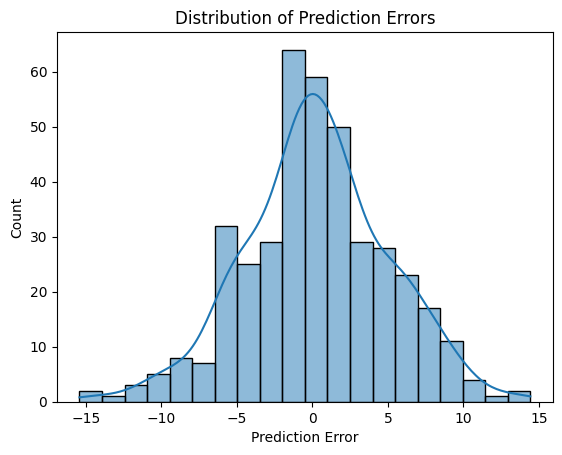

In [ ]:
sns.histplot(residuals,bins=20,kde=True)
plt.xlabel('Prediction Error')
plt.title('Distribution of Prediction Errors')
plt.show()

In [ ]:
error_analysis=pd.DataFrame({
    'actual':Y_test.values,
    'predicted':best_pred,
    'residual':residuals.values,
    'absolute_error':abs(residuals.values)
})
error_analysis.sort_values('absolute_error',ascending=False).head(10)

,actual,predicted,residual,absolute_error
274,59.142857,74.563037,-15.420180,15.420180
33,89.000000,74.563037,14.436963,14.436963
56,65.142857,79.154309,-14.011452,14.011452
57,88.000000,74.922683,13.077317,13.077317
243,61.428571,74.479844,-13.051273,13.051273
190,93.428571,80.568535,12.860036,12.860036
333,63.142857,74.532203,-11.389346,11.389346
346,70.285714,81.332669,-11.046955,11.046955
185,92.285714,81.332669,10.953045,10.953045
323,70.142857,81.084711,-10.941854,10.941854


In [ ]:
gbr=best_model.named_steps['gradient_boosting']
preprocessor_final=best_model.named_steps['preprocessor']
feature_names_final=preprocessor_final.get_feature_names_out()
importance_final=gbr.feature_importances_
final_importance=pd.DataFrame({
    'feature':feature_names_final,
    'importance':importance_final
}).sort_values('importance',ascending=False)
final_importance.head(10)

,feature,importance
1,num__weekly_self_study_hours,0.532130
11,cat__career_aspiration_Business Owner,0.321706
14,cat__career_aspiration_Doctor,0.053095
8,cat__career_aspiration_Accountant,0.024248
23,cat__career_aspiration_Unknown,0.021318
17,cat__career_aspiration_Lawyer,0.012731
19,cat__career_aspiration_Scientist,0.008939
0,num__absence_days,0.007136
18,cat__career_aspiration_Real Estate Developer,0.003151
15,cat__career_aspiration_Game Developer,0.003033


In [ ]:
career_analysis=df.groupby('career_aspiration').agg(
    students=('overall_score','count'),
    average_score=('overall_score','mean')
).sort_values('average_score',ascending=False)

career_analysis

,students,average_score
career_aspiration,,
Doctor,119,89.678271
Scientist,39,86.435897
Lawyer,138,84.157350
Writer,32,84.053571
Construction Engineer,68,83.470588
Designer,56,82.405612
Software Engineer,315,82.214966
Banker,169,81.868977
Game Developer,63,81.784580


In [ ]:
import joblib

joblib.dump(best_model,'student_performance_model.pkl')

['student_performance_model.pkl']

In [ ]:
import os

os.path.exists('student_performance_model.pkl')

True

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 103.0 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model=joblib.load('student_performance_model.pkl')

st.title("Student Academic Performance Predictor")
st.caption("Machine Learning project using student behavioral and academic activity data.")
st.divider()

st.write("Enter the student's information to predict their overall academic score.")

col1,col2=st.columns(2)

with col1:
    gender=st.selectbox("Gender",["female","male"])

with col2:
    part_time_job=st.selectbox("Part-time Job",[False,True])

col1,col2=st.columns(2)

with col1:
    absence_days=st.number_input("Absence Days",min_value=0,max_value=10,value=0)

with col2:
    extracurricular_activities=st.selectbox("Extracurricular Activities",[False,True])

col1,col2=st.columns(2)

with col1:
    weekly_self_study_hours=st.number_input("Weekly Self Study Hours",min_value=0,max_value=50,value=10)

with col2:
    career_aspiration=st.selectbox("Career Aspiration",[
        "Software Engineer",
        "Business Owner",
        "Unknown",
        "Banker",
        "Lawyer",
        "Accountant",
        "Doctor",
        "Real Estate Developer",
        "Stock Investor",
        "Construction Engineer",
        "Artist",
        "Game Developer",
        "Government Officer",
        "Teacher",
        "Designer",
        "Scientist",
        "Writer"
    ])

input_data=pd.DataFrame({
    'gender':[gender],
    'part_time_job':[part_time_job],
    'absence_days':[absence_days],
    'extracurricular_activities':[extracurricular_activities],
    'weekly_self_study_hours':[weekly_self_study_hours],
    'career_aspiration':[career_aspiration]
})

if st.button("Predict Performance"):
    prediction=model.predict(input_data)[0]

    if prediction>=85:
        performance="High"
    elif prediction>=75:
        performance="Moderate"
    else:
        performance="Lower"

    st.success(f"Predicted Overall Score: {prediction:.2f} / 100")
    st.info(f"Predicted Performance Band: {performance}")
    st.progress(min(prediction/100,1.0))

st.divider()
st.subheader("About the Model")
st.write("This application uses a Gradient Boosting regression model to predict a student's overall academic score.")
st.write("The model was trained using student study habits, attendance-related information, extracurricular activities, gender, part-time job status, and career aspiration.")

st.caption("Model performance on the held-out test set: MAE ≈ 3.66 | RMSE ≈ 4.74 | R² ≈ 0.477")

Overwriting app.py


In [ ]:
!streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false >/content/streamlit.log 2>&1 &

In [ ]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-kkb-use1b1-33d4kqd0ykwah-b.us-east1-1.prod.colab.dev


In [ ]:
!pkill -f "streamlit run app.py"

In [ ]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
numpy

Writing requirements.txt


In [ ]:
!cat requirements.txt

streamlit
pandas
scikit-learn
joblib
numpy


In [ ]:
%%writefile README.md
# Student Academic Performance Prediction

## Overview

This project uses machine learning to predict a student's overall academic score based on study habits, attendance-related information, extracurricular activities, gender, part-time job status, and career aspiration.

The project includes exploratory data analysis, preprocessing, multiple regression models, hyperparameter tuning, error analysis, and a Streamlit web application.

## Features

- Exploratory Data Analysis
- Numerical and categorical feature preprocessing
- One-Hot Encoding
- Multiple regression models
- Cross-validation
- Hyperparameter tuning using GridSearchCV
- Residual and error analysis
- Feature importance analysis
- Interactive Streamlit application

## Machine Learning Models

The following models were evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

Gradient Boosting achieved the strongest test-set performance among the models evaluated.

## Final Model

The final model is a tuned Gradient Boosting Regressor.

Test-set performance:

- MAE: 3.66
- RMSE: 4.74
- R²: 0.477

## Input Features

The application uses:

- Gender
- Part-time job status
- Absence days
- Extracurricular activities
- Weekly self-study hours
- Career aspiration

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Joblib
- Streamlit

## Project Structure

```text
student-performance-prediction/
│
├── Student_Academic_Performance_Prediction.ipynb
├── app.py
├── student_performance_model.pkl
├── requirements.txt
└── README.md

## Dataset

The dataset used for this project was obtained from Kaggle.

The raw dataset is not included in this repository because it contains identifying fields that are not used by the machine learning model.

The target variable, `overall_score`, is calculated as the average of the seven subject scores.

Overwriting README.md


In [ ]:
!ls -lh

total 400K
-rw-r--r-- 1 root root 2.5K Oct  2 18:04 app.py
-rw-r--r-- 1 root root 1.9K Oct  2 18:15 README.md
-rw-r--r-- 1 root root   43 Oct  2 18:05 requirements.txt
drwxr-xr-x 1 root root 4.0K Sep 16 13:26 sample_data
-rw-r--r-- 1 root root  136 Oct  2 18:04 streamlit.log
-rw-r--r-- 1 root root 158K Oct  2 17:49 student_performance_model.pkl
-rw-r--r-- 1 root root 218K Oct  2 17:45 student-scores.csv


In [ ]:
%%writefile .gitignore
student_scores.csv
streamlit.log
sample_data/
.config/
__pycache__/
.ipynb_checkpoints/
.env

Overwriting .gitignore


In [ ]:
!cat .gitignore

student_scores.csv
streamlit.log
sample_data/
.config/
__pycache__/
.ipynb_checkpoints/
.env


In [ ]:
!git init
!git config --global user.name "Harman98765"
!git config --global user.email "harmansinghantaal22@gmail.com"

Reinitialized existing Git repository in /content/.git/


In [ ]:
!git status

On branch master

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .gitignore
	new file:   README.md
	new file:   app.py
	new file:   requirements.txt
	new file:   student_performance_model.pkl

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	student-scores.csv



In [ ]:
!git check-ignore -v student_scores.csv

.gitignore:1:student_scores.csv	student_scores.csv


In [ ]:
!git add .gitignore README.md app.py requirements.txt student_performance_model.pkl

In [ ]:
!git commit -m "Initial project commit"

[master (root-commit) c276457] Initial project commit
 5 files changed, 176 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 README.md
 create mode 100644 app.py
 create mode 100644 requirements.txt
 create mode 100644 student_performance_model.pkl


In [ ]:
!git remote add origin https://github.com/Harman98765/student-academic-performance-prediction.git

In [ ]:
!git branch -M main

In [ ]:
!git push -u origin main

Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (7/7), 37.37 KiB | 4.67 MiB/s, done.
Total 7 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Harman98765/student-academic-performance-prediction.git
 * [new branch]      main -> main
branch 'main' set up to track 'origin/main'.


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	student-scores.csv

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!find /content -maxdepth 3 -name "*.ipynb" -print

In [12]:
from google.colab import files
uploaded=files.upload()

Saving Project1.ipynb to Project1.ipynb


In [8]:
!git clone https://github.com/Harman98765/student-academic-performance-prediction.git

Cloning into 'student-academic-performance-prediction'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 7 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 37.37 KiB | 1.38 MiB/s, done.


In [9]:
%cd student-academic-performance-prediction

/content/student-academic-performance-prediction


In [11]:
!ls -lh

total 172K
-rw-r--r-- 1 root root 2.5K Oct  2 18:45 app.py
-rw-r--r-- 1 root root 1.9K Oct  2 18:45 README.md
-rw-r--r-- 1 root root   43 Oct  2 18:45 requirements.txt
-rw-r--r-- 1 root root 158K Oct  2 18:45 student_performance_model.pkl


In [13]:
!ls -lh *.ipynb

-rw-r--r-- 1 root root 596K Oct  2 18:47 Project1.ipynb


In [14]:
!git add Project1.ipynb

In [15]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   Project1.ipynb



In [17]:
!git config --global user.name "Harman98765"
!git config --global user.email "harmansinghantaal22@gmail.com"

In [18]:
!git commit -m "Add project notebook"

[main ca96ab0] Add project notebook
 1 file changed, 5823 insertions(+)
 create mode 100644 Project1.ipynb


In [21]:
!git push

Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 275.20 KiB | 9.49 MiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push
remote:     
remote:     
remote:       —— GitHub Personal Access Token ——————————————————————
remote:        locations:
remote:          - commit: ca96ab05d76205f5e155f37574c1bc6b9929600d